# **🎓 Student Dropout Risk Prediction (ML)**
**Goal:** Predict whether a student will drop out (`dropout` = 1) using academic, financial, behavioural and wellbeing data.

**What this notebook contains**
1. Import libraries & load data
2. Data quality checks (missing values, duplicates, leakage)
3. Exploratory Data Analysis (EDA)
4. Feature engineering & preprocessing
5. Train models: Logistic Regression → Decision Tree → Random Forest → XGBoost → LightGBM → Ensemble
6. Compare results, tune the decision threshold
7. Evaluate best model & feature importance
8. Conclusion

## **1. Import Libraries & Load Data**

In [1]:
import pandas as pd, numpy as np, warnings
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_score,
                             recall_score, confusion_matrix, classification_report, RocCurveDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_style('whitegrid')
df = pd.read_csv('/kaggle/input/datasets/mohankrishnathalla/student-academic-performance-and-dropout-risk/student_dropout_risk_2026.csv')
print('Shape:', df.shape)
df.head()

Shape: (100000, 34)


,person_id,age,gender,nationality,first_generation,disability_status,family_income_level,scholarship_holder,tuition_up_to_date,part_time_job,...,library_visits_per_month,lms_logins_per_week,extracurricular_activities,missed_deadlines,stress_level,mental_health_support,satisfaction_score,commute_time_mins,sleep_hours,dropout
0,1,23,Male,Brazil,0,0,Low,1,0,1,...,4,16.3,0,3,8,0,6,37,5.7,0
1,2,18,Other,USA,1,1,High,1,1,0,...,3,8.4,1,1,7,0,6,15,5.4,1
2,3,24,Other,USA,0,0,High,0,1,1,...,3,11.3,1,0,2,0,3,4,4.3,0
3,4,25,Female,USA,0,1,Middle,1,1,0,...,2,13.2,1,1,5,0,7,10,6.7,0
4,5,15,Female,Canada,0,0,Low,1,1,0,...,4,7.4,1,0,7,0,10,24,5.8,0


## **2. Data Quality Checks**
We check missing values, duplicates, and possible **data leakage** (columns that would not be known before the outcome).

In [2]:
print('Missing values :', df.isnull().sum().sum())
print('Duplicate rows :', df.duplicated().sum())

# person_id is just a row number -> no predictive meaning, so we drop it
df = df.drop(columns='person_id')

# units_failed is exactly units_enrolled - units_passed (redundant, but known during the semester -> not leakage)
print('Redundancy check (should be 0):', (df.units_enrolled - df.units_passed - df.units_failed).abs().max())

Missing values : 0
Duplicate rows : 0
Redundancy check (should be 0): 0


## **3. Exploratory Data Analysis**

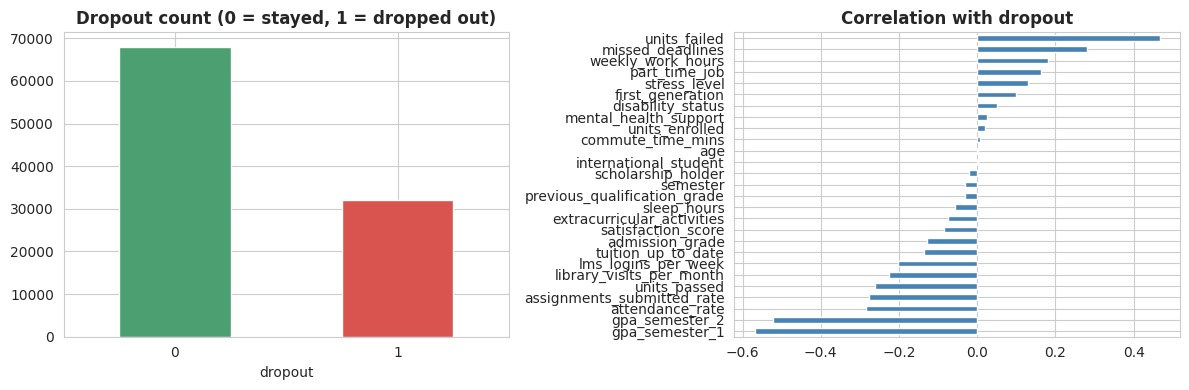

dropout
0    0.68
1    0.32
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['dropout'].value_counts().plot.bar(ax=ax[0], color=['#4C9F70', '#D9534F'])
ax[0].set_title('Dropout count (0 = stayed, 1 = dropped out)',fontweight='bold'); ax[0].tick_params(axis='x', rotation=0)
corr = df.corr(numeric_only=True)['dropout'].drop('dropout').sort_values()
corr.plot.barh(ax=ax[1], color='steelblue'); ax[1].set_title('Correlation with dropout',fontweight='bold')
plt.tight_layout(); plt.show()
print(df['dropout'].value_counts(normalize=True).round(3))

**Insight:** About 32% of students drop out (moderate imbalance). `units_failed`, GPA, attendance and missed deadlines are the strongest signals.

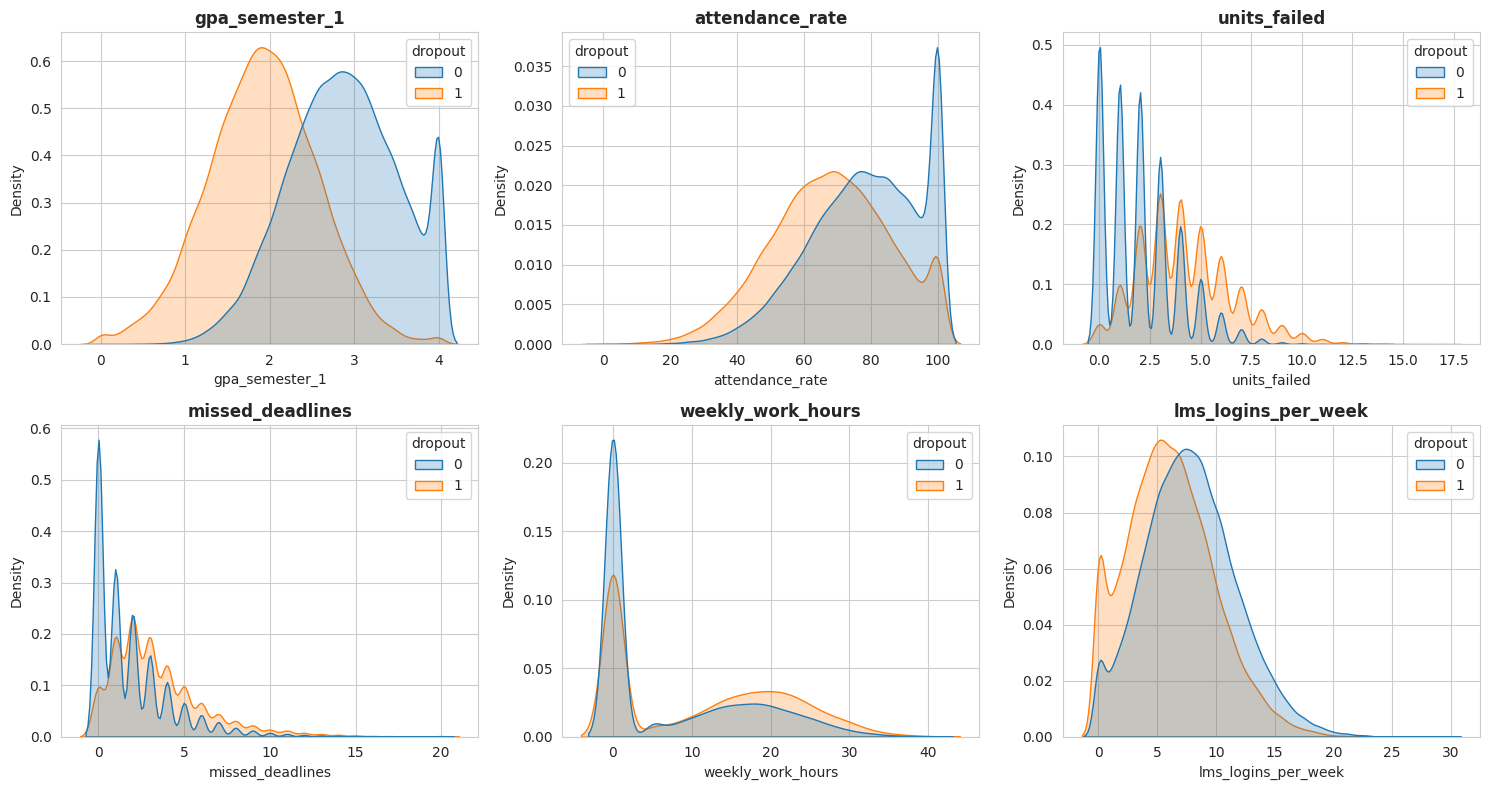

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, col in zip(ax.flat, ['gpa_semester_1', 'attendance_rate', 'units_failed', 'missed_deadlines', 'weekly_work_hours', 'lms_logins_per_week']):
    sns.kdeplot(data=df, x=col, hue='dropout', fill=True, common_norm=False, ax=a, warn_singular=False)
    a.set_title(col,fontweight='bold')
plt.tight_layout(); plt.show()

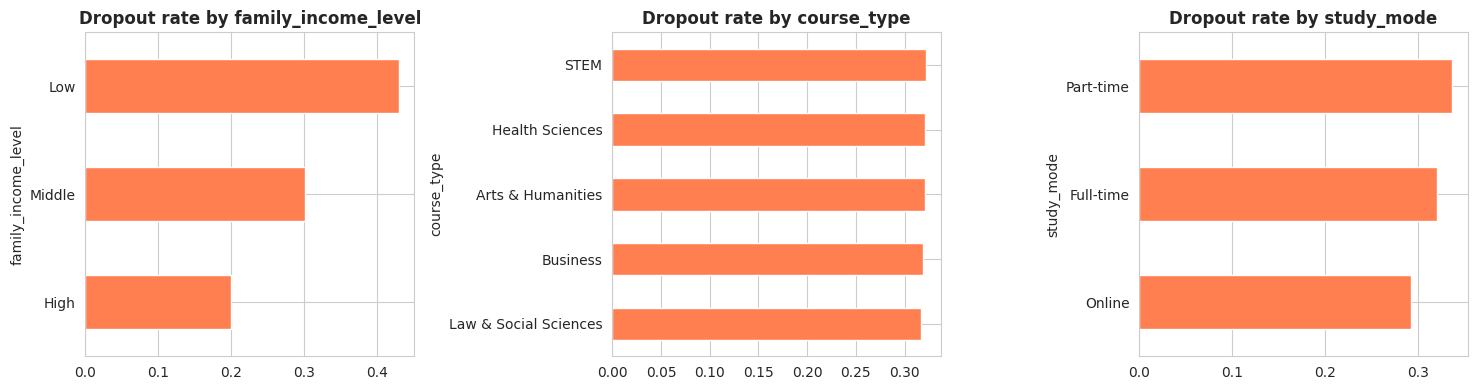

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, ['family_income_level', 'course_type', 'study_mode']):
    df.groupby(col)['dropout'].mean().sort_values().plot.barh(ax=a, color='coral')
    a.set_title(f'Dropout rate by {col}',fontweight='bold')
plt.tight_layout(); plt.show()

## **4. Feature Engineering & Preprocessing**
We add a few simple, meaningful features and one-hot encode the text columns.

In [6]:
df['pass_rate']  = df.units_passed / df.units_enrolled                    # share of units passed
df['gpa_change'] = df.gpa_semester_2 - df.gpa_semester_1                  # improving or declining?
df['gpa_avg']    = (df.gpa_semester_1 + df.gpa_semester_2) / 2
df['engagement'] = (df.attendance_rate + df.assignments_submitted_rate) / 2

X = pd.get_dummies(df.drop(columns='dropout'), drop_first=True)
y = df['dropout']

# 80/20 split, stratified so both sets keep the same dropout ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (80000, 55) | Test: (20000, 55)


## **5. Train Models (Baseline → Best)**
We start with a simple baseline and move to stronger models. All are scored on the same untouched test set.

In [7]:
models = {
    'Logistic Regression (baseline)': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, min_samples_leaf=5, n_jobs=-1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8,
                             colsample_bytree=0.8, random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
}
# Ensemble: average the probabilities of three different model types
models['Voting Ensemble'] = VotingClassifier(
    [('lr', models['Logistic Regression (baseline)']), ('xgb', models['XGBoost']), ('lgbm', models['LightGBM'])],
    voting='soft')

rows = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred, prob = m.predict(X_test), m.predict_proba(X_test)[:, 1]
    rows[name] = dict(Accuracy=accuracy_score(y_test, pred), Precision=precision_score(y_test, pred),
                      Recall=recall_score(y_test, pred), F1=f1_score(y_test, pred), ROC_AUC=roc_auc_score(y_test, prob))
results = pd.DataFrame(rows).T.round(4).sort_values('ROC_AUC', ascending=False)
results

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression (baseline),0.8402,0.7812,0.6952,0.7357,0.9031
Voting Ensemble,0.8400,0.7809,0.6949,0.7354,0.9026
XGBoost,0.8400,0.7811,0.6947,0.7354,0.9016
LightGBM,0.8373,0.7755,0.6919,0.7313,0.9009
Random Forest,0.8329,0.7852,0.6579,0.7159,0.8947
Decision Tree,0.8161,0.7549,0.6297,0.6867,0.8737


## **6. Model Comparison**

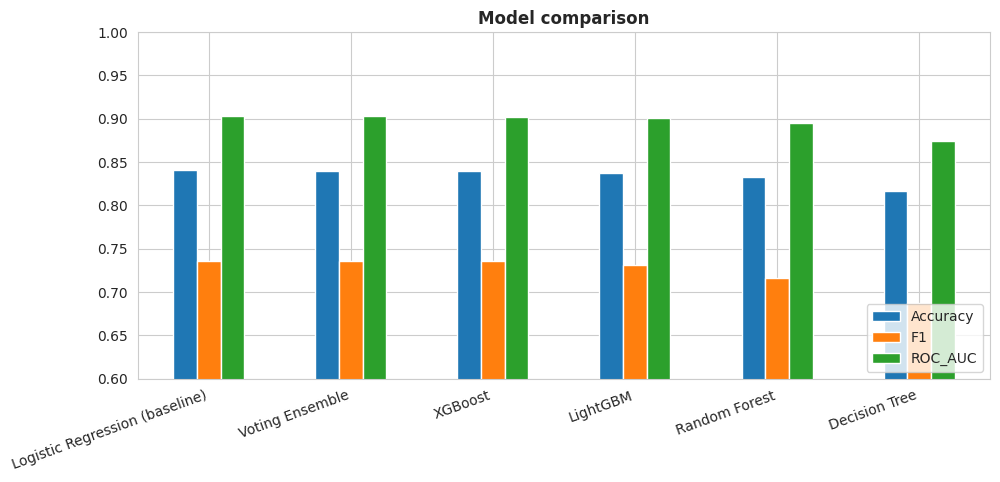

Logistic Regression (baseline)   CV ROC-AUC: 0.9037 ± 0.0021
XGBoost                          CV ROC-AUC: 0.9019 ± 0.0021
Voting Ensemble                  CV ROC-AUC: 0.9028 ± 0.0020


In [8]:
results[['Accuracy', 'F1', 'ROC_AUC']].plot.bar(figsize=(11, 4.5), ylim=(0.6, 1))
plt.title('Model comparison',fontweight='bold'); plt.xticks(rotation=20, ha='right'); plt.legend(loc='lower right'); plt.show()

# 5-fold cross-validation on the top models to make sure the score is stable (not a lucky split)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
for n in ['Logistic Regression (baseline)', 'XGBoost', 'Voting Ensemble']:
    s = cross_val_score(models[n], X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{n:32s} CV ROC-AUC: {s.mean():.4f} ± {s.std():.4f}')

**Insight:** Simple Logistic Regression is as good as the boosted trees, which suggests the dropout signal is mostly *linear and additive*. The remaining ~16% error is likely noise in the data.

## **7. Handling Imbalance: SMOTE vs. Threshold Tuning**
Dropouts are the minority (32%). We test whether SMOTE helps, and whether simply moving the probability threshold is better.

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
Xs, ys = SMOTE(random_state=42).fit_resample(X_train, y_train)          # SMOTE on TRAIN only (no leakage)
lr_s = clone(models['Logistic Regression (baseline)']).fit(Xs, ys)
p = lr_s.predict(X_test)
print(f'LR + SMOTE -> Acc {accuracy_score(y_test, p):.4f} | F1 {f1_score(y_test, p):.4f} | Recall {recall_score(y_test, p):.4f}')

# Threshold tuning: choose the cut-off that maximises F1, using CROSS-VALIDATED train predictions (test stays untouched)
from sklearn.model_selection import cross_val_predict
best = models['Voting Ensemble']
oof = cross_val_predict(clone(best), X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
ths = np.arange(0.2, 0.7, 0.01)
th = ths[np.argmax([f1_score(y_train, oof > t) for t in ths])]
print('Best threshold from training data:', round(th, 2))

LR + SMOTE -> Acc 0.8387 | F1 0.7378 | Recall 0.7094
Best threshold from training data: 0.4


## **8. Final Evaluation (Best Model)**

Accuracy 0.8350 | F1 0.7490 | Recall 0.7694 | ROC-AUC 0.9026

              precision    recall  f1-score   support

      Stayed       0.89      0.87      0.88     13599
 Dropped out       0.73      0.77      0.75      6401

    accuracy                           0.83     20000
   macro avg       0.81      0.82      0.81     20000
weighted avg       0.84      0.83      0.84     20000



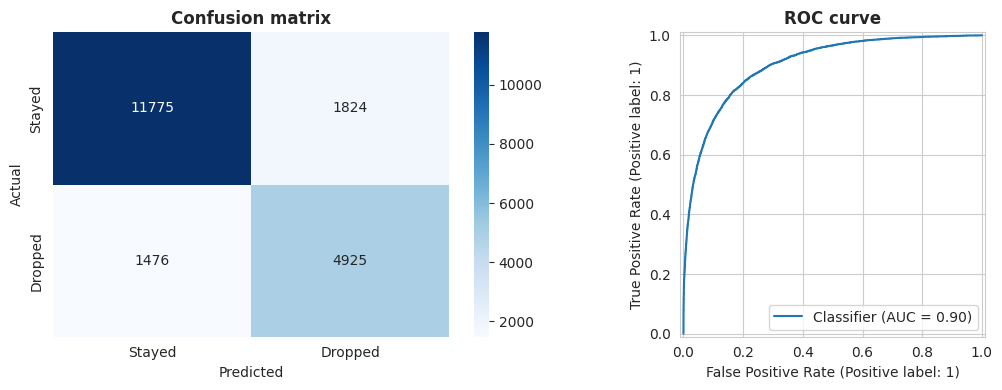

In [10]:
prob = best.predict_proba(X_test)[:, 1]
pred = (prob > th).astype(int)
print(f'Accuracy {accuracy_score(y_test, pred):.4f} | F1 {f1_score(y_test, pred):.4f} | '
      f'Recall {recall_score(y_test, pred):.4f} | ROC-AUC {roc_auc_score(y_test, prob):.4f}\n')
print(classification_report(y_test, pred, target_names=['Stayed', 'Dropped out']))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Stayed', 'Dropped'], yticklabels=['Stayed', 'Dropped'])
ax[0].set_title('Confusion matrix',fontweight='bold'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')
RocCurveDisplay.from_predictions(y_test, prob, ax=ax[1]); ax[1].set_title('ROC curve',fontweight='bold')
plt.tight_layout(); plt.show()

## **9. Which Features Matter Most?**

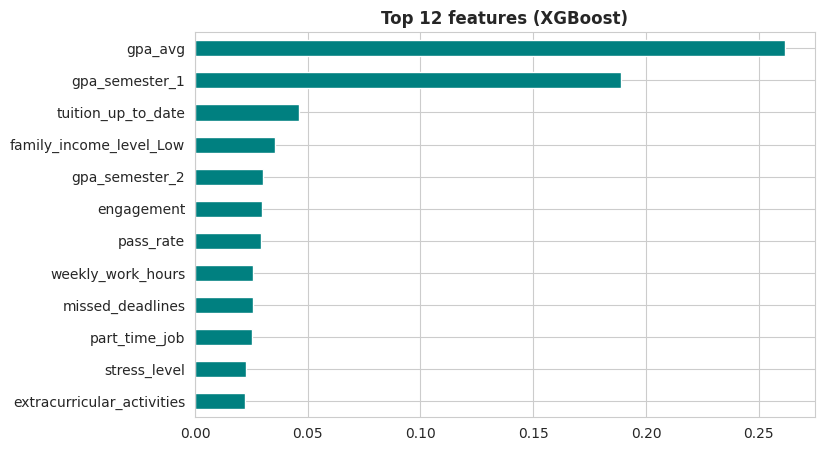

In [11]:
imp = pd.Series(models['XGBoost'].feature_importances_, index=X.columns).sort_values().tail(12)
imp.plot.barh(figsize=(8, 5), color='teal'); plt.title('Top 12 features (XGBoost)',fontweight='bold'); plt.show()

## **10. Conclusion**
- **Data:** 100,000 students, 33 features, no missing values or duplicates. About 32% dropped out.
- **Best model:** Soft-voting ensemble (Logistic Regression + XGBoost + LightGBM), ≈**84% accuracy and ≈0.90 ROC-AUC**, stable across 5-fold cross-validation (CV ROC-AUC ≈ 0.90 ± 0.002).
- **Model comparison:** Logistic Regression, XGBoost, LightGBM and the ensemble are within ~0.3% of each other (plain Logistic Regression is even marginally ahead on ROC-AUC); Decision Tree and Random Forest are behind. The dropout signal is mostly linear, and the ~16% remaining error looks like natural noise in the data rather than a modelling weakness.
- **Imbalance:** SMOTE gave only a tiny gain (F1 0.736 → 0.738). Tuning the decision threshold (chosen on training data only) worked better for catching dropouts: recall rose from ≈0.69 to ≈0.77 and F1 to ≈0.75, at a small cost in accuracy (≈83.5%).
- **Key drivers of dropout:** number of failed units, low GPA, low attendance and assignment submission, missed deadlines, and heavy work hours.
- **Practical use:** Universities can flag high-risk students early (low GPA + failed units + low attendance) and offer tutoring, financial or work-load support.
- **Next steps:** Try hyperparameter search (Optuna), add SHAP explanations, and check fairness across gender and nationality before real-world use.